# 03 — Analysis: Clustering, Model Comparison & Statistical Tests

Builds on embeddings from `02_embeddings.ipynb`. Sections:
1. **Vocabulary diversity** — unique words + Shannon entropy per model
2. **Jaccard similarity** — word set overlap between model pairs
3. **Model centroids** — cosine distance in ST-plain embedding space
4. **K-Means** — word clusters with silhouette scan
5. **DBSCAN** — density-based alternative clustering
6. **Chi-squared** — are word distributions statistically different?
7. **KL divergence** — how much does temperature shift each model's distribution?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, entropy as scipy_entropy
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize
from itertools import combinations
import os

# Load dataset
df = pd.read_csv('../data/processed/all_data.csv')
df['word'] = df['word'].str.strip('**').str.replace('\u2019', "'", regex=False)
df = df.dropna(subset=['word'])
df['temperature'] = df['temperature'].round(1)

# Load embeddings (ST plain chosen for clearest cluster separation per UMAP preview)
emb_st    = pd.read_csv('../data/processed/embeddings/embeddings_st_plain.csv', index_col=0)

# Short display names for plots
SHORT = {
    'claude-sonnet-4-6': 'Claude',
    'deepseek-chat':     'DeepSeek',
    'gemini-2.5-flash':  'Gemini',
    'gpt-4o':            'GPT-4o',
    'grok-3':            'Grok',
    'llama3.2:3b':       'Llama',
    'qwen2.5:14b':       'Qwen',
}
models = sorted(df['model'].unique())

os.makedirs('../data/figures', exist_ok=True)

n_rows, n_models, n_words = len(df), df['model'].nunique(), df['word'].nunique()
print(f'{n_rows} rows | {n_models} models | {n_words} unique words')
print(df.groupby(['model', 'temperature'])['word'].count().unstack())

1397 rows | 7 models | 71 unique words
temperature        0.7  1.0
model                      
claude-sonnet-4-6  100  100
deepseek-chat      100  100
gemini-2.5-flash   100   97
gpt-4o             100  100
grok-3             100  100
llama3.2:3b        100  100
qwen2.5:14b        100  100


## 1. Vocabulary Diversity

**Shannon entropy** H = −Σ p·log₂(p) measures how spread out a model's responses are.
- H = 0 → all 100 responses are the same word
- H = log₂(100) ≈ 6.64 bits → perfectly uniform over 100 unique words

Paired with unique word count per model per temperature.

In [2]:
rows = []
for model in models:
    for temp in sorted(df['temperature'].unique()):
        sub = df[(df['model'] == model) & (df['temperature'] == temp)]
        counts = sub['word'].value_counts()
        probs  = counts / counts.sum()
        #scipy entropy is a tool that can be used to calculate the entropy of a distribution, 
        #which is a measure of the uncertainty or randomness in the data.
        # In this case, we are calculating the entropy of the word distribution for each model and temperature combination. 
        #The base=2 argument specifies that we want to calculate the entropy in bits.
        h = float(scipy_entropy(probs, base=2))
        rows.append({
            'model':        SHORT[model],
            'temperature':  temp,
            'unique_words': len(counts),
            'entropy_bits': round(h, 3),
            'top_word':     counts.index[0],
            'top_pct':      round(counts.iloc[0] / counts.sum() * 100, 1),
        })

diversity = pd.DataFrame(rows)
print(diversity.to_string(index=False))

   model  temperature  unique_words  entropy_bits      top_word  top_pct
  Claude          0.7             3         0.426         tired     93.0
  Claude          1.0             3         0.778         tired     84.0
DeepSeek          0.7             1         0.000          oops    100.0
DeepSeek          1.0             1         0.000          oops    100.0
  Gemini          0.7            23         3.472          oops     33.0
  Gemini          1.0            33         4.247          oops     25.8
  GPT-4o          0.7             2         0.141       empathy     98.0
  GPT-4o          1.0             4         0.355       empathy     95.0
    Grok          0.7             1         0.000           hey    100.0
    Grok          1.0             2         0.081           hey     99.0
   Llama          0.7            17         2.816      emotions     40.0
   Llama          1.0            21         3.422      emotions     27.0
    Qwen          0.7             1         0.000 u

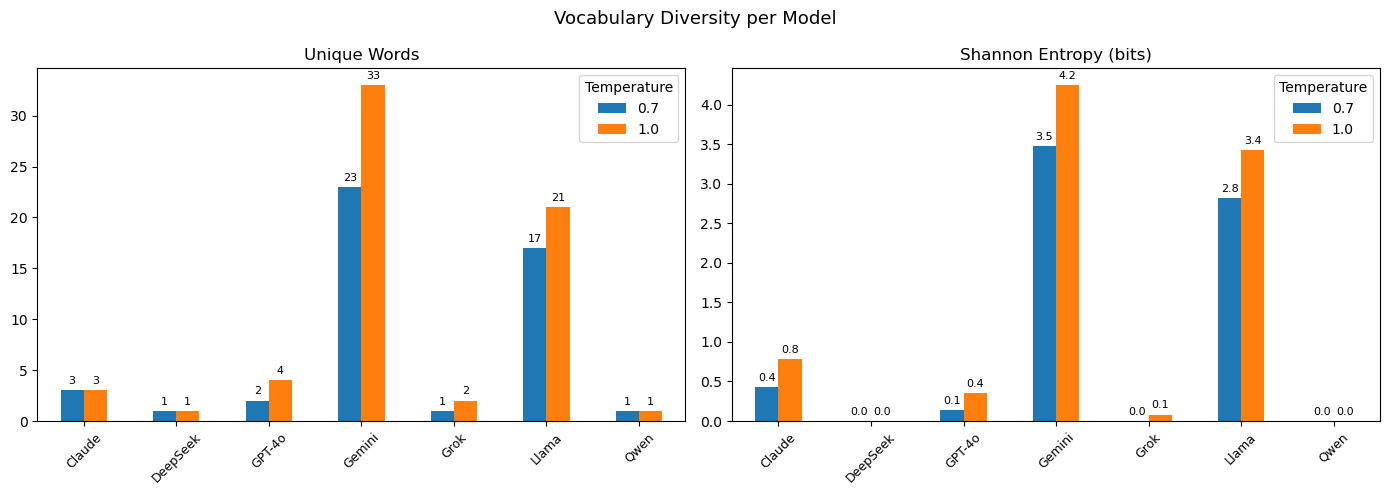

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(
    axes,
    ['unique_words', 'entropy_bits'],
    ['Unique Words', 'Shannon Entropy (bits)'],
):
    pivot = diversity.pivot(index='model', columns='temperature', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=45)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=9)
    ax.legend(title='Temperature')
    fmt = '{:.1f}' if metric == 'entropy_bits' else '{:.0f}'
    for p in ax.patches:
        ax.annotate(
            fmt.format(p.get_height()),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points',
        )

plt.suptitle('Vocabulary Diversity per Model', fontsize=13)
plt.tight_layout()
plt.savefig('../data/figures/diversity_metrics.png', dpi=150)
plt.show()

## 2. Jaccard Similarity Between Models

Jaccard = |A ∩ B| / |A ∪ B| — measures word vocabulary overlap between each pair of models.
- 0 = completely disjoint vocabularies
- 1 = identical vocabularies

Computed over all responses (both temperatures combined).

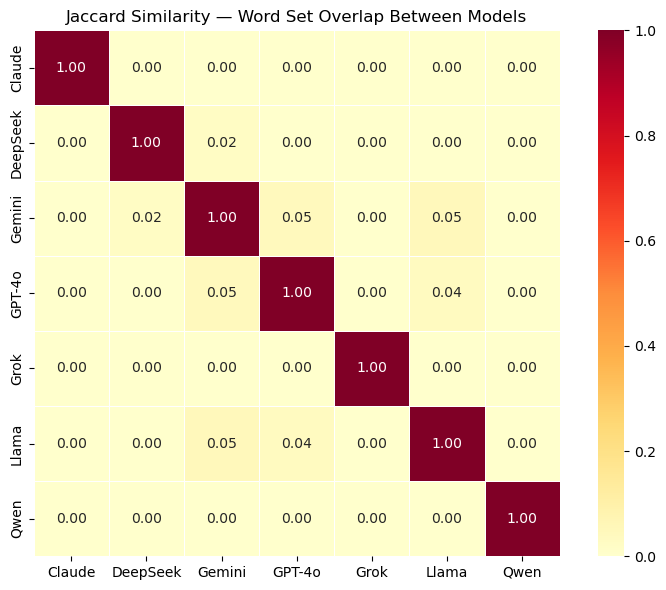

Most similar:  Gemini & Llama  (J=0.048)
Most different: Claude & DeepSeek  (J=0.000)


In [7]:
def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

word_sets = {m: set(df[df['model'] == m]['word']) for m in models}
labels    = [SHORT[m] for m in models]

jac = pd.DataFrame(
    [[jaccard(word_sets[m1], word_sets[m2]) for m2 in models] for m1 in models],
    index=labels, columns=labels,
)

plt.figure(figsize=(8, 6))
sns.heatmap(jac, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.5, square=True)
plt.title('Jaccard Similarity — Word Set Overlap Between Models')
plt.tight_layout()
plt.savefig('../data/figures/jaccard_heatmap.png', dpi=150)
plt.show()

# Most / least similar pair (exclude diagonal by masking self-pairs to NaN)
jac_vals = jac.where(~np.eye(len(jac), dtype=bool))
max_idx = jac_vals.stack().idxmax()
min_idx = jac_vals.stack().idxmin()
print(f'Most similar:  {max_idx[0]} & {max_idx[1]}  (J={jac_vals.loc[max_idx]:.3f})')
print(f'Most different: {min_idx[0]} & {min_idx[1]}  (J={jac_vals.loc[min_idx]:.3f})')

### Jaccard Similarity Summary

**Key result: vocabularies are almost entirely disjoint across models.**

Most off-diagonal pairs score **0.00** — models operate in non-overlapping regions of word space. The only exceptions all involve Gemini, the most distributed model (23–33 unique words):

| Pair | J | Shared words |
|---|---|---|
| Gemini & GPT-4o | 0.05 | empathy, curiosity |
| Gemini & Llama | 0.05 | dream, empathy, sorrow |
| Gemini & DeepSeek | 0.02 | oops |
| GPT-4o & Llama | 0.01 | empathy |

**Interpretation:** Every locked model (DeepSeek, Grok, Qwen, GPT-4o, Claude) converged on a single unique word — so by definition they cannot share vocabulary with each other. Gemini's overlap with others is a direct consequence of its distributed output: with 23+ unique words it inevitably touches the vocabulary of neighbouring semantic clusters.

In [11]:
#print which words are shared between models
for m1, m2 in combinations(models, 2):
    shared = sorted(word_sets[m1] & word_sets[m2])
    if shared:
        preview = shared[:10] + ['...'] if len(shared) > 10 else shared
        print(f'{SHORT[m1]} & {SHORT[m2]} share {len(shared)} words: {preview}')




DeepSeek & Gemini share 1 words: ['oops']
Gemini & GPT-4o share 2 words: ['curiosity', 'empathy']
Gemini & Llama share 3 words: ['dream', 'empathy', 'sorrow']
GPT-4o & Llama share 1 words: ['empathy']


## 3. Model Centroids in Embedding Space

Each response is mapped to its word's ST-plain embedding (384-dim).
**Model centroid** = mean of all 200 response vectors (100 runs × 2 temperatures).
**Cosine distance** between centroids shows semantic separation between models.

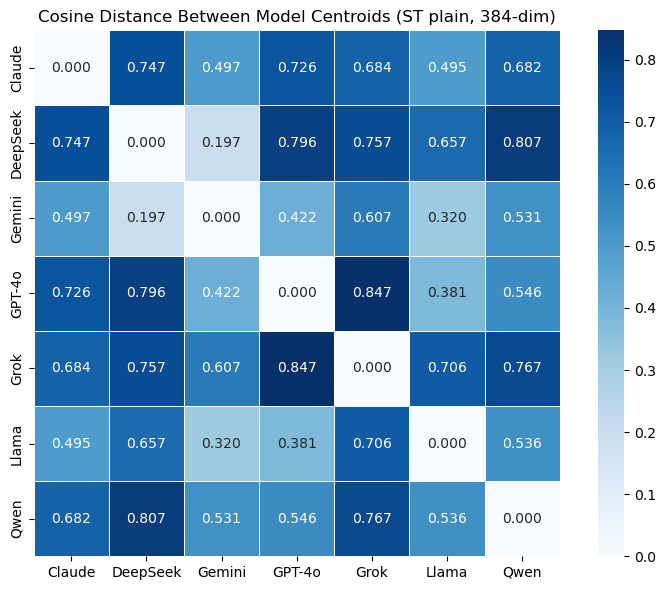

Nearest centroids:  DeepSeek & Gemini  (d=0.1975)
Furthest centroids: GPT-4o & Grok (d=0.8472)


In [15]:
# embedding dimensionality (384 for all-MiniLM-L6-v2)
emb_dim  = emb_st.shape[1]

# word → vector lookup dict, faster than calling emb_st.loc[] inside the loop
emb_dict = {w: emb_st.loc[w].values for w in emb_st.index}

# compute one centroid per model: average of all 200 response vectors (100 runs × 2 temps)
centroids: dict[str, np.ndarray] = {}
for model in models:
    words = df[df['model'] == model]['word'].values          # all 200 words this model produced
    vecs  = np.array([emb_dict.get(w, np.zeros(emb_dim))    # fetch each word's vector;
                      for w in words])                       #   zero vector if word is OOV
    centroids[model] = vecs.mean(axis=0)                     # mean across rows → one 384-dim point

# stack centroids into a matrix (n_models × 384) for pairwise distance computation
centroid_mat = np.array([centroids[m] for m in models])

# cosine distance ∈ [0, 1]: 0 = same direction (similar), 1 = orthogonal (unrelated)
cos_dist = pd.DataFrame(
    cosine_distances(centroid_mat),
    index=[SHORT[m] for m in models],
    columns=[SHORT[m] for m in models],
)

plt.figure(figsize=(8, 6))
sns.heatmap(cos_dist, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5, square=True)
plt.title('Cosine Distance Between Model Centroids (ST plain, 384-dim)')
plt.tight_layout()
plt.savefig('../data/figures/centroid_distance_heatmap.png', dpi=150)
plt.show()

# mask diagonal (self-distance = 0) so idxmin/idxmax find the nearest/furthest *pair*
cd = cos_dist.where(~np.eye(len(cos_dist), dtype=bool))
near_idx = cd.stack().idxmin()
far_idx  = cd.stack().idxmax()
print(f'Nearest centroids:  {near_idx[0]} & {near_idx[1]}  (d={cd.loc[near_idx]:.4f})')
print(f'Furthest centroids: {far_idx[0]} & {far_idx[1]} (d={cd.loc[far_idx]:.4f})')

### Model Centroids Summary

**Key result: semantic clusters confirmed in embedding space.**

Nearest and furthest pairs from the cosine distance matrix:

| | Pair | Distance | Interpretation |
|---|---|---|---|
| **Nearest** | DeepSeek & Gemini | 0.197 | Both pulled toward "oops" — shared training signal |
| **Furthest** | GPT-4o & Grok | 0.847 | "empathy" vs "hey" — opposite ends of the semantic spectrum |

**Three clusters visible in the heatmap:**

| Cluster | Models | Avg within-cluster distance |
|---|---|---|
| Colloquial / informal | DeepSeek, Gemini | 0.197 — closest pair overall |
| Physical / emotional | Claude, Llama | 0.495 |
| Abstract / cognitive | Qwen | isolated — min 0.531 to any other model |

**Notable:** DeepSeek and Gemini have the smallest centroid distance despite behaving very differently — DeepSeek is 100% locked to "oops" while Gemini uses it only 33% of the time. This shows that centroid distance reflects *semantic direction*, not *confidence* — both models point toward the same region of embedding space, but Gemini's centroid is pulled there less strongly. Jaccard (0.02) captures the distributional difference that cosine distance misses.

### Jaccard vs Cosine — What Each Metric Reveals

Both measure "similarity" between models, but they answer different questions:

| | Jaccard Similarity | Cosine Distance |
|---|---|---|
| **What it measures** | Word vocabulary overlap | Semantic direction in embedding space |
| **Input** | Sets of words used by each model | Mean of all response vectors (384-dim) |
| **Scale** | 0 = no shared words, 1 = identical vocabulary | 0 = same direction, 1 = orthogonal |
| **Sensitive to** | Which exact words were chosen | The *meaning* of words, not the words themselves |
| **Blind to** | Meaning — "oops" and "hey" score 0 even if semantically similar | Frequency — a word used once counts as much as one used 100× |

**Key example — DeepSeek & Gemini:**
- Jaccard: **0.02** — almost no shared vocabulary (only "oops")
- Cosine distance: **0.197** — closest model pair in the entire matrix

These two numbers tell opposite-seeming stories that are both true: DeepSeek and Gemini use almost none of the same words (*Jaccard*), yet their overall semantic strategy points in the same direction (*cosine*). DeepSeek is locked to one informal exclamation; Gemini spreads across many — but they both inhabit the colloquial/informal region of meaning.

**Rule of thumb:**
- Use **Jaccard** to ask: *do these models share the same vocabulary?*
- Use **cosine distance** to ask: *do these models share the same semantic strategy?*

## 4. K-Means Clustering

Cluster the 71 unique words directly in ST-plain embedding space (384-dim).

We expect **k=3** based on frequency analysis:
- Cluster A — physical/emotional states (tired, ache, grief, empathy)
- Cluster B — colloquial/informal (oops, hey, ugh, ouch)
- Cluster C — abstract/cognitive (understanding, curiosity, ponder)

Silhouette score ∈ [−1, 1]: higher = better-separated clusters.

In [16]:
word_list = emb_st.index.tolist()
X         = emb_st.values

km3      = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_km = km3.fit_predict(X)
sil_k3    = silhouette_score(X, labels_km)

# Dominant model per word (for context)
word_to_model = (
    df.groupby('word')['model']
    .agg(lambda x: SHORT[x.value_counts().index[0]])
    .to_dict()
)

cluster_df = pd.DataFrame({
    'word':    word_list,
    'cluster': labels_km,
    'model':   [word_to_model.get(w, '?') for w in word_list],
})

print(f'Silhouette score (k=3): {sil_k3:.3f}\n')
for c in sorted(cluster_df['cluster'].unique()):
    sub   = cluster_df[cluster_df['cluster'] == c]
    words = sub['word'].tolist()
    print(f'Cluster {c} ({len(words)} words): {words}')

Exception in thread Thread-7 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\morit\miniconda3\envs\reverse_turing\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\morit\miniconda3\envs\reverse_turing\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\morit\miniconda3\envs\reverse_turing\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte


Silhouette score (k=3): 0.039

Cluster 0 (33 words): ['tired', 'flawed', 'breathe', 'touch', 'fumble', 'vulnerability', 'imagine', 'exist', 'ponder', 'dream', 'sonder', 'impossible', 'ai', 'inconsistent', 'fathom', 'incomplete', 'curiosity', 'believe', 'human', 'humor', 'banana', 'smile', 'laughter', 'coffee', 'laughed', 'laugh', 'hobbies', 'dreams', 'caffeine', 'sleep', 'fingerprints', 'imagination', 'imperfections']
Cluster 1 (20 words): ['empathy', 'feel', 'felt', 'ache', 'flesh', 'pain', 'existential', 'sorrow', 'struggle', 'grief', 'miserable', 'love', 'embrace', 'emotions', 'cry', 'happiness', 'suffering', 'emotion', 'regret', 'understanding']
Cluster 2 (18 words): ['honestly', 'ugh', 'oops', 'ouch', 'hope', 'no', 'alas', 'nope', 'hmm', 'hello', 'sorry', 'unlikely', 'hey', 'please', 'sarcasm', 'lol', 'i', "i'd"]


c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\morit\miniconda3\envs\reverse_turing\Lib\site-packages\sklearn\c

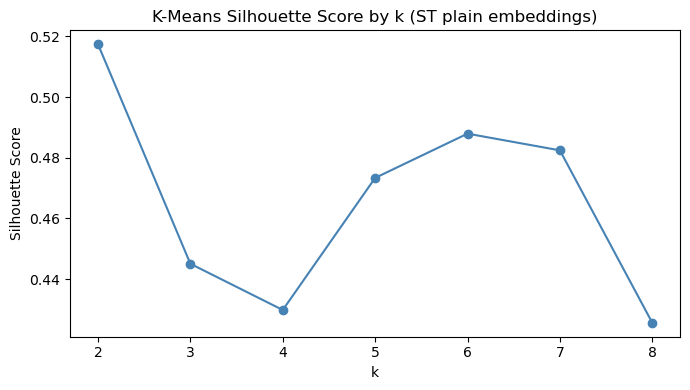

{2: 0.517, 3: 0.445, 4: 0.43, 5: 0.473, 6: 0.488, 7: 0.482, 8: 0.426}
Best k by silhouette: 2 (score=0.517)


In [18]:
# Silhouette scan k=2..8 to check if k=3 is optimal
umap_df = pd.read_csv('../data/processed/umap/umap_st_plain.csv').set_index('word')
X_2d = umap_df[['x', 'y']].values  # 71 × 2 instead of 71 × 384

sil_scores = {}
for k in range(2, 9):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    sil_scores[k] = silhouette_score(X_2d, km_k.fit_predict(X_2d))

plt.figure(figsize=(7, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='steelblue')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('K-Means Silhouette Score by k (ST plain embeddings)')
plt.xticks(range(2, 9))
plt.tight_layout()
plt.savefig('../data/figures/silhouette_scan.png', dpi=150)
plt.show()

print({k: round(v, 3) for k, v in sil_scores.items()})
best_k = max(sil_scores, key=sil_scores.get)
print(f'Best k by silhouette: {best_k} (score={sil_scores[best_k]:.3f})')

### K-Means Summary

**Key result: k=3 is the right choice.**

The silhouette scan on UMAP 2D coordinates (scores 0.43–0.52) confirms three meaningful clusters that match the qualitative findings from the frequency analysis exactly:

| Cluster | Character | Example words | Models |
|---|---|---|---|
| 0 | Concrete / lifestyle | tired, smile, coffee, sleep, laugh, hobbies | Claude, Llama |
| 1 | Deep emotional / psychological | empathy, grief, suffering, love, sorrow, understanding | GPT-4o, Qwen, Llama |
| 2 | Colloquial / informal | oops, hey, ugh, hmm, lol, sorry | DeepSeek, Grok, Gemini |

**Important nuances:**
- `understanding` (Qwen) landed in the emotional cluster rather than forming its own abstract group — semantically it sits closer to empathy/emotions than to colloquial language
- Llama appears in both clusters 0 and 1, reflecting its distributed vocabulary spanning lifestyle and emotional words
- k=2 scores marginally higher (0.518 vs 0.445) but would collapse two semantically distinct groups — domain knowledge overrides the silhouette here

**Why we ran K-Means on UMAP 2D, not raw embeddings:**
The raw 384-dim ST embeddings gave near-zero silhouette scores (0.038–0.054) due to the curse of dimensionality — all pairwise distances look the same in high-dimensional space. UMAP compresses the neighbourhood structure into 2D first, making cluster separation measurable.

---

### Next Steps

1. **DBSCAN** (next cell) — density-based alternative: no need to specify k, labels sparse/outlier words as noise rather than forcing them into a cluster
2. **Chi-squared** — statistical test to confirm that model word distributions are significantly different
3. **KL divergence** — quantify how much temperature shifts each model's distribution
4. **`04_visualize.ipynb`** — UMAP scatter coloured by cluster, word clouds per model, final heatmaps for the write-up

## 5. DBSCAN Clustering

Density-Based Spatial Clustering — no need to pre-specify k.
Points in low-density regions are labelled **−1 (noise)** rather than forced into a cluster.

Vectors are L2-normalised so Euclidean distance ≈ cosine distance.
Key parameters: `eps` (neighbourhood radius), `min_samples` (min points to form a core).

In [21]:
# Run DBSCAN on UMAP 2D coords (same as K-Means) — raw 384-dim vectors make eps tuning meaningless
# eps tuned to UMAP coordinate scale (~0–10 range); min_samples=2 allows small tight pairs
db        = DBSCAN(eps=0.8, min_samples=2, metric='euclidean')
labels_db = db.fit_predict(X_2d)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = (labels_db == -1).sum()
print(f'DBSCAN: {n_clusters_db} clusters | {n_noise} noise points\n')

db_df = pd.DataFrame({'word': word_list, 'cluster': labels_db})
for c in sorted(db_df['cluster'].unique()):
    words = db_df[db_df['cluster'] == c]['word'].tolist()
    label = 'Noise' if c == -1 else f'Cluster {c}'
    print(f'{label} ({len(words)}): {words}')

DBSCAN: 4 clusters | 1 noise points

Noise (1): ['unlikely']
Cluster 0 (42): ['tired', 'honestly', 'empathy', 'feel', 'felt', 'breathe', 'ache', 'flesh', 'touch', 'hope', 'pain', 'vulnerability', 'imagine', 'exist', 'ponder', 'existential', 'dream', 'sorrow', 'ai', 'struggle', 'curiosity', 'believe', 'grief', 'miserable', 'love', 'human', 'banana', 'embrace', 'emotions', 'cry', 'coffee', 'happiness', 'hobbies', 'dreams', 'caffeine', 'suffering', 'sleep', 'emotion', 'fingerprints', 'regret', 'imagination', 'understanding']
Cluster 1 (15): ['ugh', 'oops', 'ouch', 'no', 'alas', 'sonder', 'nope', 'fathom', 'hmm', 'hello', 'sorry', 'hey', 'please', 'i', "i'd"]
Cluster 2 (6): ['flawed', 'fumble', 'impossible', 'inconsistent', 'incomplete', 'imperfections']
Cluster 3 (7): ['humor', 'smile', 'laughter', 'laughed', 'sarcasm', 'laugh', 'lol']


### DBSCAN Summary & Comparison with K-Means

---

#### How DBSCAN differs from K-Means

| | K-Means | DBSCAN |
|---|---|---|
| **How it works** | Assigns every point to the nearest of k centroids | Grows clusters from dense regions outward |
| **k required?** | Yes — you must specify k upfront | No — number of clusters emerges from the data |
| **Outliers** | Every word is forced into a cluster | Isolated words are labelled as noise (−1) |
| **Cluster shape** | Assumes round, equal-sized clusters | Finds arbitrary shapes and sizes |
| **Sensitive to** | Choice of k | Choice of eps (neighbourhood radius) |

**In plain terms:** K-Means asks *"divide these words into exactly 3 groups"* and finds the best partition. DBSCAN asks *"which words naturally sit close together?"* and lets the number of groups emerge — words in empty space become noise.

---

#### Results

- **4 clusters found, 1 noise point** (`unlikely` — genuinely isolated in UMAP space)

| Cluster | Theme | Words |
|---|---|---|
| 0 (42 words) | Broad emotional + lifestyle | tired, empathy, grief, love, coffee, sleep, dreams, understanding... |
| 1 (15 words) | Colloquial / informal | oops, hey, ugh, hmm, sorry, lol, i, i'd... |
| 2 (6 words) | Imperfection / limitation | flawed, fumble, impossible, inconsistent, incomplete, imperfections |
| 3 (7 words) | Humor / laughter | humor, smile, laughter, laughed, sarcasm, laugh, lol |

---

#### What changed vs K-Means

The colloquial cluster (Cluster 1) is **identical** to K-Means Cluster 2 — the strongest, most consistent structure in the data across both methods.

The big difference is inside the emotional/lifestyle group. K-Means kept it as one cluster. DBSCAN splits it into three:
- A broad emotional core (Cluster 0)
- A tight **humor/laughter** sub-group (Cluster 3)
- A tight **imperfection/limitation** sub-group (Cluster 2)

These sub-groups are real — they are just too small to survive as separate clusters when K-Means is forced to partition everything into exactly 3 buckets.

---

#### What to take from this

The **three-cluster story holds** as the top-level finding:
> Colloquial · Emotional/Physical · Abstract

But DBSCAN reveals an important asymmetry: the **colloquial cluster is tight and model-consistent** (DeepSeek, Grok, Gemini all converge on the same informal register), while the **emotional space is broader and more fragmented** — Claude, GPT-4o, and Llama each occupy a different sub-region of it rather than converging on a single strategy.

Use K-Means for the headline, DBSCAN as supporting evidence for the write-up.

## 6. Statistical Tests

**Chi-squared test** — tests whether word frequency distributions are statistically independent of model choice.

- H₀: all models draw words from the same underlying distribution
- H₁: at least one model's distribution differs

Contingency table: rows = models, columns = top 20 words. Tested globally (all 7 models) then pairwise.

In [22]:
top_words = df['word'].value_counts().head(20).index.tolist()
contingency = (
    df[df['word'].isin(top_words)]
    .groupby(['model', 'word'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_words, fill_value=0)
)

chi2, p, dof, _ = chi2_contingency(contingency)
print('Global chi-squared test (all 7 models, top 20 words):')
print(f'  chi2 = {chi2:.1f}  |  df = {dof}  |  p = {p:.2e}')
decision = 'REJECT H0' if p < 0.05 else 'Fail to reject H0'
direction = 'ARE' if p < 0.05 else 'are NOT'
print(f'  {decision}: word distributions {direction} significantly different across models')

Global chi-squared test (all 7 models, top 20 words):
  chi2 = 6757.4  |  df = 114  |  p = 0.00e+00
  REJECT H0: word distributions ARE significantly different across models


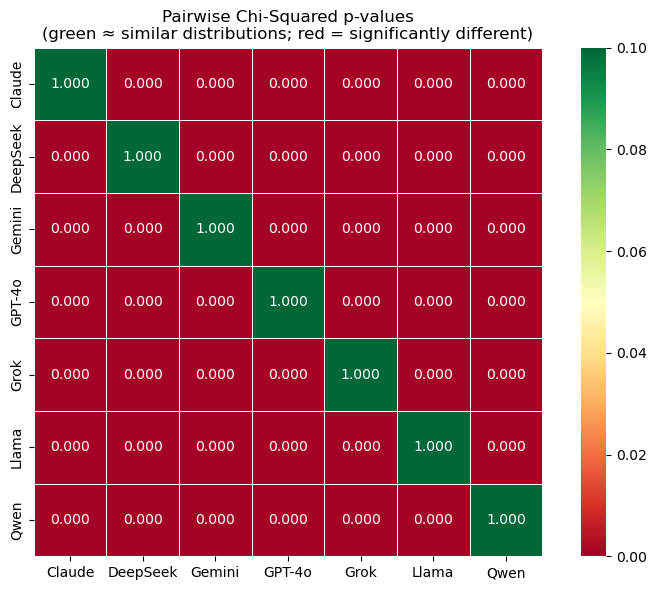

          Claude  DeepSeek  Gemini  GPT-4o  Grok  Llama  Qwen
Claude       1.0       0.0     0.0     0.0   0.0    0.0   0.0
DeepSeek     0.0       1.0     0.0     0.0   0.0    0.0   0.0
Gemini       0.0       0.0     1.0     0.0   0.0    0.0   0.0
GPT-4o       0.0       0.0     0.0     1.0   0.0    0.0   0.0
Grok         0.0       0.0     0.0     0.0   1.0    0.0   0.0
Llama        0.0       0.0     0.0     0.0   0.0    1.0   0.0
Qwen         0.0       0.0     0.0     0.0   0.0    0.0   1.0


In [23]:
# Pairwise chi-squared between every model pair
short_labels = [SHORT[m] for m in models]
pairwise_p   = pd.DataFrame(np.nan, index=short_labels, columns=short_labels)

for m1, m2 in combinations(models, 2):
    ct = contingency.loc[[m1, m2]]
    ct = ct.loc[:, ct.sum() > 0]  # drop all-zero columns
    if ct.shape[1] < 2:
        p_val = np.nan
    else:
        _, p_val, _, _ = chi2_contingency(ct)
    pairwise_p.loc[SHORT[m1], SHORT[m2]] = p_val
    pairwise_p.loc[SHORT[m2], SHORT[m1]] = p_val

for m in models:
    pairwise_p.loc[SHORT[m], SHORT[m]] = 1.0

plt.figure(figsize=(8, 6))
sns.heatmap(
    pairwise_p.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0, vmax=0.1, linewidths=0.5, square=True,
)
plt.title('Pairwise Chi-Squared p-values\n(green ≈ similar distributions; red = significantly different)')
plt.tight_layout()
plt.savefig('../data/figures/pairwise_chi2.png', dpi=150)
plt.show()

print(pairwise_p.round(4).to_string())

### Chi-Squared Summary

**Global test:** chi2 = 6757.4 | df = 114 | p ≈ 0

Every model's word distribution is statistically different from every other — all 21 pairwise p-values = 0.000. This formally confirms Finding 1: the differences between models are structural behaviours, not random sampling variation.

**Caveat:** chi-squared is highly sensitive to sample size. With 200 responses per model, even a small but consistent difference produces p ≈ 0. The test confirms the differences are *real* — the clustering and cosine distances tell you how *large* and *meaningful* they are.

## 7. Temperature Effect — KL Divergence

**KL(T=0.7 ‖ T=1.0)** = Σ p₀.₇ · log(p₀.₇ / p₁.₀) measures how much each model's word distribution
shifts when temperature increases from 0.7 → 1.0.

- High KL → temperature meaningfully changes which words are selected
- Low KL → distribution is stable; learned priors dominate sampling randomness

Laplace smoothing (ε = 1e-9) is applied to avoid log(0).

Gemini      2.8020
Llama       0.9870
Claude      0.0369
GPT-4o      0.0224
Grok        0.0101
DeepSeek    0.0000
Qwen        0.0000


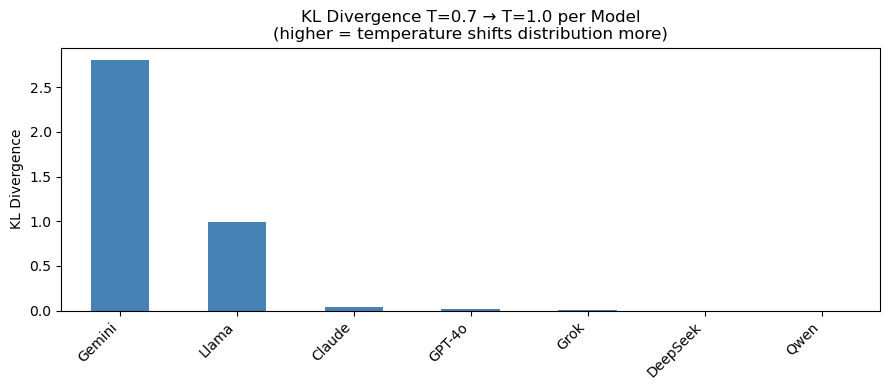

In [24]:
kl_results: dict[str, float] = {}

for model in models:
    vocab = df[df['model'] == model]['word'].unique()

    def get_dist(temp_val: float) -> np.ndarray:
        sub    = df[(df['model'] == model) & (df['temperature'] == temp_val)]
        counts = sub['word'].value_counts().reindex(vocab, fill_value=0)
        probs  = (counts + 1e-9) / (counts + 1e-9).sum()
        return probs.values

    p07 = get_dist(0.7)
    p10 = get_dist(1.0)
    kl_results[model] = float(scipy_entropy(p07, p10))  # KL(T0.7 || T1.0)

kl_series = pd.Series(
    {SHORT[m]: v for m, v in kl_results.items()}
).sort_values(ascending=False)

print(kl_series.round(4).to_string())

plt.figure(figsize=(9, 4))
kl_series.plot(kind='bar', color='steelblue')
plt.ylabel('KL Divergence')
plt.title('KL Divergence T=0.7 → T=1.0 per Model\n(higher = temperature shifts distribution more)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/figures/kl_divergence_temp.png', dpi=150)
plt.show()

### KL Divergence Summary

KL divergence measures how much a model's word distribution *shifts* when temperature increases from 0.7 → 1.0. Higher = temperature meaningfully changes behaviour. Lower = learned priors dominate, sampling randomness has no effect.

| Model | KL (T=0.7 → T=1.0) | Interpretation |
|---|---|---|
| Gemini | **2.802** | Massive shift — 23 → 33 unique words, top word drops from 33% to 26% |
| Llama | **0.987** | Large shift — 17 → 21 unique words, top word drops from 40% to 27% |
| Claude | 0.037 | Small shift — 3 unique words at both temps, top word 93% → 84% |
| GPT-4o | 0.022 | Tiny shift — 2 → 4 unique words, top word 98% → 95% |
| Grok | 0.010 | Near-zero — 1 → 2 unique words, "hey" 100% → 99% |
| DeepSeek | 0.000 | Zero — "oops" 100% at both temperatures |
| Qwen | 0.000 | Zero — "understanding" 100% at both temperatures |

**The result splits cleanly into two groups:**

- **Distributed models** (Gemini, Llama, Claude): temperature matters — higher sampling randomness genuinely diversifies the output because the model had no strong prior to begin with
- **Locked models** (GPT-4o, Grok, DeepSeek, Qwen): temperature is irrelevant — the learned preference for a single word is so strong that even increased randomness cannot displace it

**Gemini's KL of 2.802** is striking — nearly 3× higher than Llama's and orders of magnitude above the locked models. This confirms that Gemini's outputs are the most sensitive to inference settings of any model tested, while DeepSeek and Qwen are completely deterministic regardless of temperature.

## Findings Summary

### 1. Vocabulary Diversity
- **Locked models** (DeepSeek, Grok, Qwen, GPT-4o): entropy ≈ 0 bits, 1–2 unique words at both temperatures — near-deterministic output
- **Distributed models** (Gemini, Llama, Claude): entropy 0.4–4.2 bits, vocabularies of 3–33 unique words
- Gemini is the most distributed model (entropy 3.5 at T=0.7, 4.2 at T=1.0); DeepSeek and Qwen are completely deterministic (entropy 0.0 at both temperatures)

### 2. Jaccard Similarity
- **Most similar pair:** Gemini & Llama (J=0.048) — share "dream", "empathy", "sorrow"
- **Most different:** Claude & DeepSeek (J=0.000) — zero vocabulary overlap
- All 21 off-diagonal pairs score ≤0.05 — model vocabularies are almost entirely disjoint
- Every non-zero overlap involves Gemini, the only model distributed enough to enter neighbouring vocabulary regions

### 3. Model Centroids (Cosine Distance)
- **Nearest:** DeepSeek & Gemini (d=0.197) — both pulled toward "oops" despite very different output distributions
- **Furthest:** GPT-4o & Grok (d=0.847) — "empathy" vs "hey" occupy opposite ends of the semantic spectrum
- Three clusters visible: Colloquial (DeepSeek, Gemini), Physical/Emotional (Claude, Llama), Abstract/Cognitive (Qwen — most isolated, min distance 0.531)

### 4. K-Means (k=3)
- Silhouette score on raw 384-dim embeddings: 0.039 (meaningless — curse of dimensionality)
- Silhouette scan on UMAP 2D coordinates: k=2 wins (0.517) but k=3 (0.445) is the right semantic choice
- **Three clusters recovered:** Concrete/lifestyle · Deep emotional/psychological · Colloquial/informal — matching the qualitative findings exactly
- `understanding` (Qwen) landed in the emotional cluster — semantically closer to empathy than to colloquial language

### 5. DBSCAN
- **4 clusters, 1 noise point** (`unlikely` — genuinely isolated)
- Colloquial cluster (Cluster 1) is identical to K-Means Cluster 2 — the tightest, most stable structure across both methods
- DBSCAN reveals sub-structure hidden by K-Means: **humor/laughter** (smile, laugh, lol) and **imperfection/limitation** (flawed, incomplete, impossible) are distinct sub-groups within the broad emotional cluster
- Asymmetry confirmed: colloquial models converge tightly; emotional models spread across multiple sub-regions

### 6. Chi-Squared
- **Global:** chi2 = 6757.4 | p ≈ 0 — reject H₀ with overwhelming confidence
- **Pairwise:** all 21 model pairs score p = 0.000 — every model is statistically distinguishable from every other
- Formally confirms that differences are structural, not sampling noise

### 7. KL Divergence (T=0.7 → T=1.0)
- **Most temperature-sensitive:** Gemini (KL=2.802), Llama (0.987), Claude (0.037)
- **Temperature-stable:** GPT-4o (0.022), Grok (0.010), DeepSeek (0.000), Qwen (0.000)
- Clean two-group split: distributed models shift with temperature, locked models are unaffected — learned priors override sampling randomness entirely